# 🐶🐱 Clasificación de Imágenes: Perros vs Gatos

En este proyecto se implementa una Red Neuronal Convolucional (CNN) para clasificar imágenes de perros y gatos.

El dataset proviene del conjunto utilizado originalmente en el CAPTCHA "Asirra", el cual fue considerado en su momento un reto para sistemas de visión artificial.

El objetivo es entrenar un modelo capaz de generalizar correctamente ante variaciones en iluminación, orientación, encuadre y número de animales por imagen.

In [1]:
import os #me permiti manipular carpetas
import cv2 #libreria especializa en procesamiento de imagenes 
import numpy as np
import matplotlib.pyplot as plt
import shutil
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


In [2]:
dataset_dogvscats = "C:/Users/ajose/Downloads/dogs-vs-cats-proyectoneuronales/dogs-vs-cats/train"

In [3]:
IMG_SIZE = 200
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_dogvscats,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_dogvscats,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)


Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


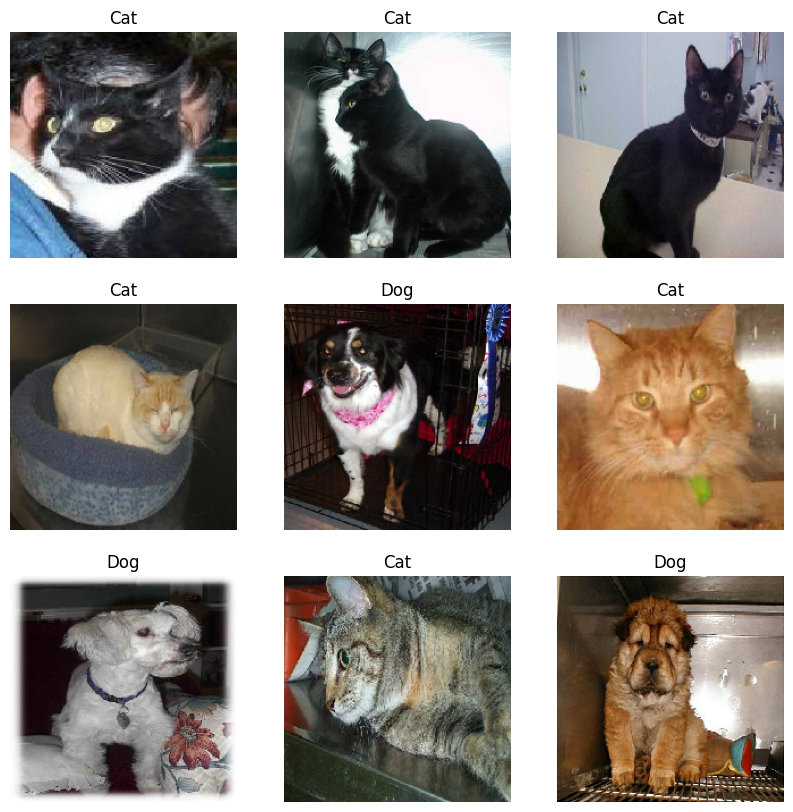

In [4]:
images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(9):
    
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    
    if labels[i] == 1:
        plt.title("Dog")
    else:
        plt.title("Cat")
        
    plt.axis("off")

plt.show()


In [5]:
checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True)

In [6]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(200,200,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\ajose\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,760,641 (33.42 MB)

 Trainable params: 8,760,641 (33.42 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.6090 - loss: 0.6674
Epoch 1: val_accuracy improved from None to 0.73840, saving model to best_model.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 264s 421ms/step - accuracy: 0.6611 - loss: 0.6109 - val_accuracy: 0.7384 - val_loss: 0.5261
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.7596 - loss: 0.5083
Epoch 2: val_accuracy improved from 0.73840 to 0.78520, saving model to best_model.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 266s 426ms/step - accuracy: 0.7655 - loss: 0.4939 - val_accuracy: 0.7852 - val_loss: 0.4565
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.8035 - loss: 0.4345
Epoch 3: val_accuracy did not improve from 0.78520
625/625 ━━━━━━━━━━━━━━━━━━━━ 262s 419ms/step - accuracy: 0.8056 - loss: 0.4308 - val_accuracy: 0.7796 - val_loss: 0.4626
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.8426 - loss: 0.3612
Epoch 4: val_accuracy improved from 0.78520 to 0.79900, saving model to best_model.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 267s 427ms/step - accuracy: 0.8376 - loss: 0.3714 - val_accuracy: 0.7990 - val_loss: 0.4479
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.8698 - loss: 0.3001
Epoch 5: val_accuracy improved from 0.79900 to 0.81320, saving model to best_model.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 265s 424ms/step - accuracy: 0.8687 - loss: 0.3041 - val_accuracy: 0.8132 - val_loss: 0.4359
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.9102 - loss: 0.2254
Epoch 6: val_accuracy improved from 0.81320 to 0.82400, saving model to best_model.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 265s 423ms/step - accuracy: 0.9061 - loss: 0.2299 - val_accuracy: 0.8240 - val_loss: 0.4464
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.9370 - loss: 0.1611
Epoch 7: val_accuracy did not improve from 0.82400
625/625 ━━━━━━━━━━━━━━━━━━━━ 249s 399ms/step - accuracy: 0.9338 - loss: 0.1710 - val_accuracy: 0.8214 - val_loss: 0.4803
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9563 - loss: 0.1168
Epoch 8: val_accuracy did not improve from 0.82400
625/625 ━━━━━━━━━━━━━━━━━━━━ 4045s 6s/step - accuracy: 0.9527 - loss: 0.1289 - val_accuracy: 0.8220 - val_loss: 0.5305


In [8]:
loss, accuracy = model.evaluate(val_data)
print("Accuracy:", accuracy)


157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - accuracy: 0.8132 - loss: 0.4359
Accuracy: 0.8131999969482422


In [9]:
model.save("dogs_vs_cats_model_final.h5")

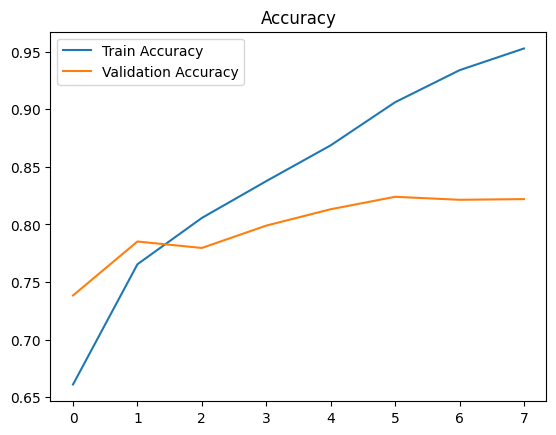

In [10]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()


## Análisis del Entrenamiento

Durante el entrenamiento se observa un incremento progresivo en la accuracy de entrenamiento, alcanzando valores cercanos al 95%.

Sin embargo, la accuracy de validación se estabiliza alrededor del 81–82%, lo que indica la presencia de cierto sobreajuste.

Este comportamiento es común en modelos convolucionales profundos entrenados desde cero, especialmente cuando la arquitectura es compleja.

A pesar de ello, el modelo mantiene una capacidad de generalización aceptable, obteniendo aproximadamente un 81% de precisión en el conjunto de validación.